# 09 – Scientific Limitations and Final Synthesis

## Objective

This notebook evaluates the limitations of the study and synthesizes the findings from the complete machine-learning analysis.

The central question is:

> What can we genuinely conclude from this study, and what are the major limitations?

The analysis focuses on:

1. Feature-space coverage
2. Missingness and dataset composition
3. Class imbalance
4. Measurement uncertainty
5. Observational selection effects
6. Host-star group structure
7. Final scientific synthesis

This notebook is not intended to develop another major predictive model.

Instead, it evaluates the context in which the previous results should be interpreted.

## Overview

The project investigated whether measurable host-star properties could be used to predict whether an exoplanet belongs to the gas-giant class.

The analysis progressed through:

- Dataset exploration and cleaning
- Construction of the machine-learning problem
- Model comparison and selection
- Model interpretation and error analysis
- Probability calibration
- Generalization and subgroup analysis
- Feature contribution and scientific pattern agreement
- Robustness to target definitions and measurement perturbations

This final notebook evaluates the limitations of the resulting conclusions and summarizes the complete body of evidence.

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    GroupShuffleSplit,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [2]:
FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

TARGET = "gas_giant"

X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze("columns")

X = pd.concat(
    [
        X_train,
        X_test
    ],
    ignore_index=True
)

y = pd.concat(
    [
        y_train,
        y_test
    ],
    ignore_index=True
)

print(
    "Modeling dataset shape:",
    X.shape
)

print(
    "Target shape:",
    y.shape
)

Modeling dataset shape: (27540, 3)
Target shape: (27540,)


## Feature-Space Coverage

A model is most trustworthy in regions of feature space that are well represented by the training data.

Sparse regions may lead to less reliable predictions because the model has fewer comparable observations from which to learn.

The following analysis examines the distribution of the three modeling features.

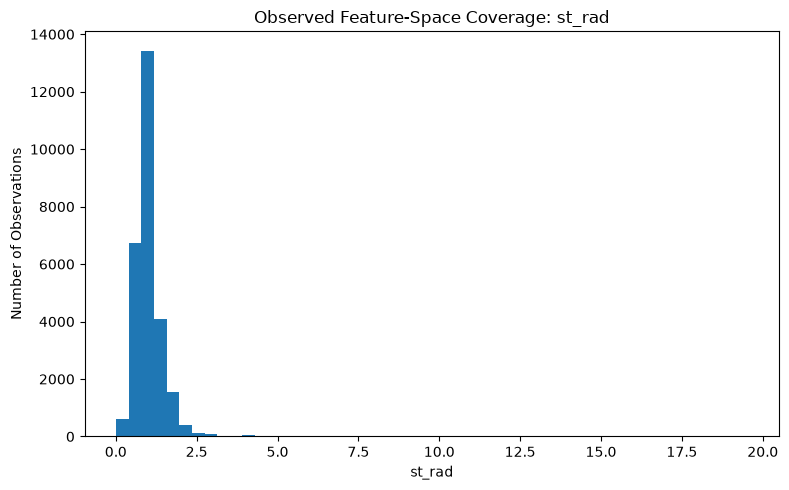

In [3]:
feature = "st_rad"

feature_values = X[feature].dropna()

plt.figure(figsize=(8, 5))

plt.hist(
    feature_values,
    bins=50
)

plt.xlabel(feature)
plt.ylabel("Number of Observations")
plt.title(
    "Observed Feature-Space Coverage: st_rad"
)

plt.tight_layout()
plt.show()
plt.close()

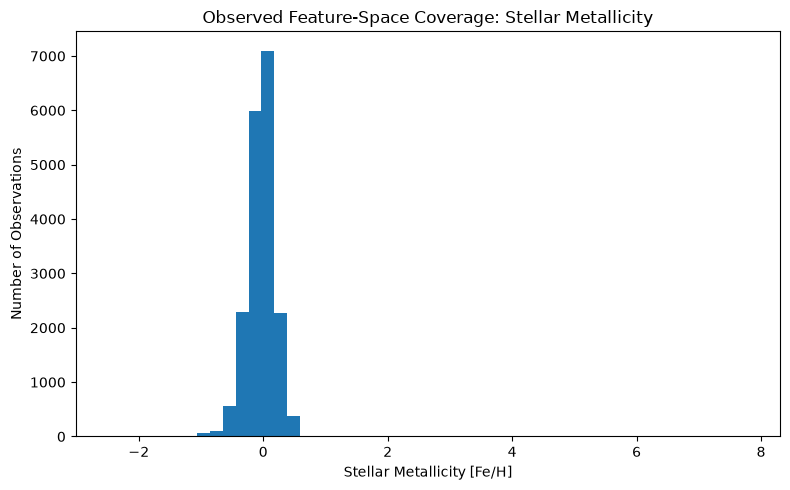

In [4]:
feature = "st_met"

feature_values = X[feature].dropna()

plt.figure(figsize=(8, 5))

plt.hist(
    feature_values,
    bins=50
)

plt.xlabel("Stellar Metallicity [Fe/H]")
plt.ylabel("Number of Observations")

plt.title(
    "Observed Feature-Space Coverage: Stellar Metallicity"
)

plt.tight_layout()

plt.show()

plt.close()

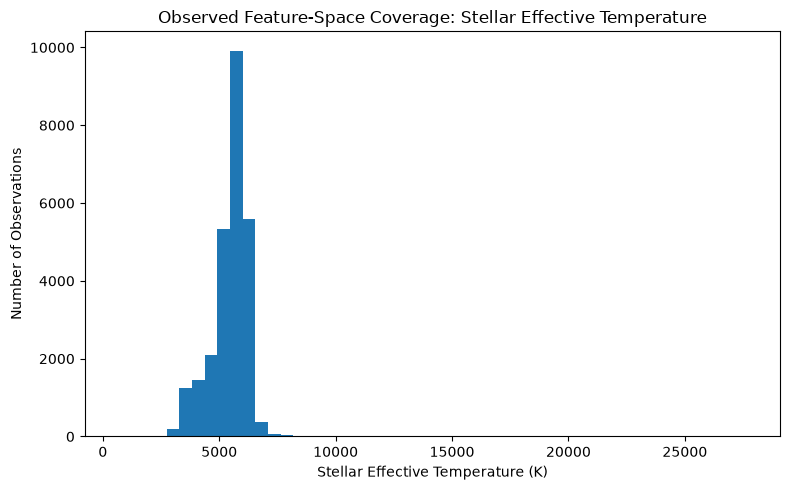

In [5]:
feature = "st_teff"

feature_values = X[feature].dropna()

plt.figure(figsize=(8, 5))

plt.hist(
    feature_values,
    bins=50
)

plt.xlabel("Stellar Effective Temperature (K)")
plt.ylabel("Number of Observations")

plt.title(
    "Observed Feature-Space Coverage: Stellar Effective Temperature"
)

plt.tight_layout()

plt.show()

plt.close()

In [6]:
coverage_summary = []

for feature in FEATURES:

    feature_values = X[feature].dropna()

    coverage_summary.append({

        "Feature": feature,

        "Minimum":
            feature_values.min(),

        "1st Percentile":
            feature_values.quantile(0.01),

        "25th Percentile":
            feature_values.quantile(0.25),

        "Median":
            feature_values.median(),

        "75th Percentile":
            feature_values.quantile(0.75),

        "99th Percentile":
            feature_values.quantile(0.99),

        "Maximum":
            feature_values.max(),

        "Observations":
            feature_values.count()
    })

coverage_summary = pd.DataFrame(
    coverage_summary
)

coverage_summary.round(3)

,Feature,Minimum,1st Percentile,25th Percentile,Median,75th Percentile,99th Percentile,Maximum,Observations
0,st_teff,575.000,3339.000,5120.00,5641.000,5978.000,6760.300,27730.00,26371
1,st_rad,0.012,0.288,0.78,0.934,1.157,2.551,19.53,27096
2,st_met,-2.500,-0.660,-0.16,-0.020,0.100,0.440,7.79,18794


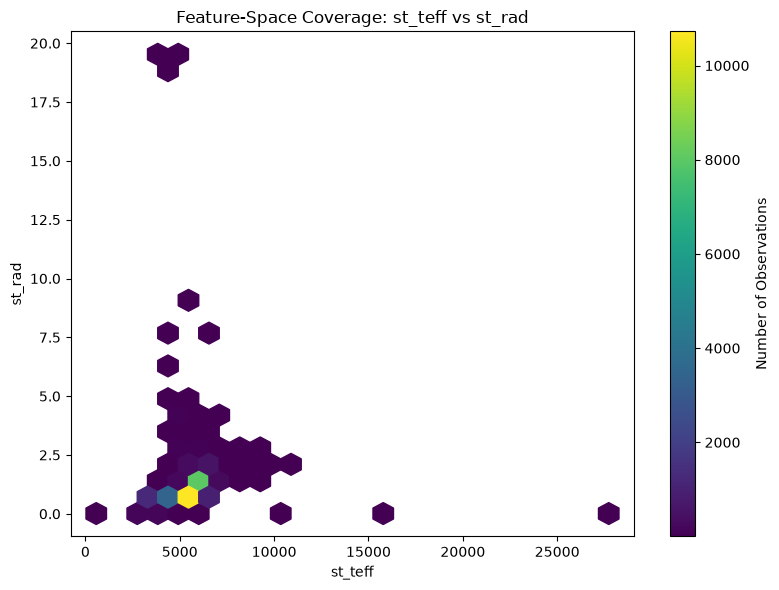

In [8]:
x_feature = "st_teff"
y_feature = "st_rad"

x_values = X[x_feature]
y_values = X[y_feature]

valid = (
    x_values.notna()
    &
    y_values.notna()
)

plt.figure(figsize=(8, 6))

plt.hexbin(
    x_values[valid],
    y_values[valid],
    gridsize=25,
    mincnt=1
)

plt.xlabel(x_feature)
plt.ylabel(y_feature)

plt.title(
    f"Feature-Space Coverage: {x_feature} vs {y_feature}"
)

plt.colorbar(
    label="Number of Observations"
)

plt.tight_layout()

plt.show()

plt.close()

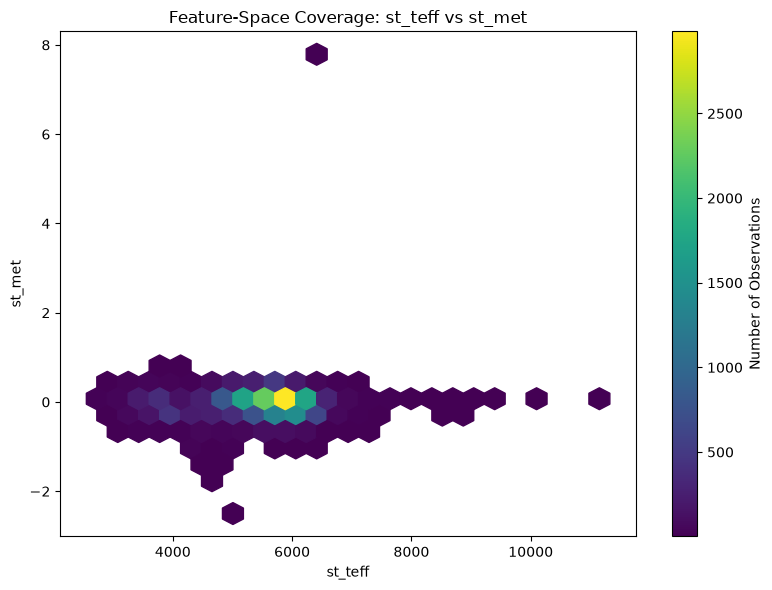

In [10]:
x_feature = "st_teff"
y_feature = "st_met"

x_values = X[x_feature]
y_values = X[y_feature]

valid = (
    x_values.notna()
    &
    y_values.notna()
)

plt.figure(figsize=(8, 6))

plt.hexbin(
    x_values[valid],
    y_values[valid],
    gridsize=25,
    mincnt=1
)

plt.xlabel(x_feature)
plt.ylabel(y_feature)

plt.title(
    f"Feature-Space Coverage: {x_feature} vs {y_feature}"
)

plt.colorbar(
    label="Number of Observations"
)

plt.tight_layout()

plt.show()

plt.close()

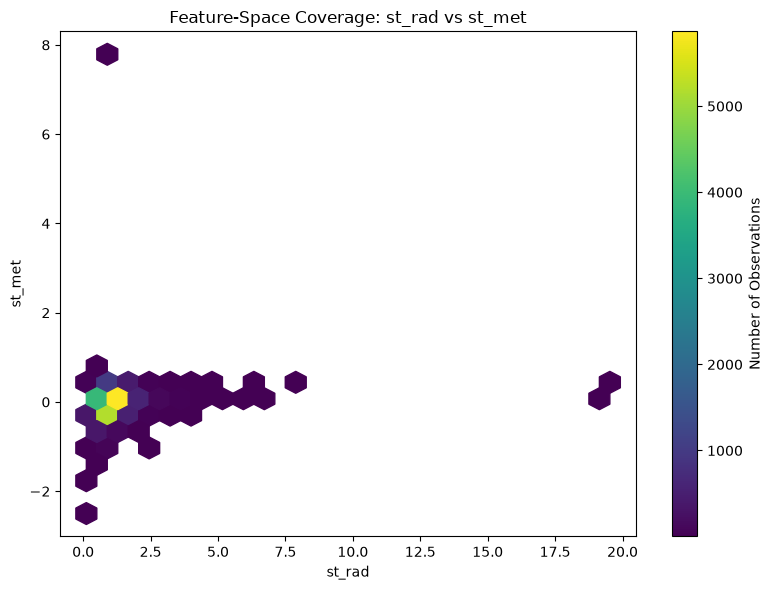

In [11]:
x_feature = "st_rad"
y_feature = "st_met"

x_values = X[x_feature]
y_values = X[y_feature]

valid = (
    x_values.notna()
    &
    y_values.notna()
)

plt.figure(figsize=(8, 6))

plt.hexbin(
    x_values[valid],
    y_values[valid],
    gridsize=25,
    mincnt=1
)

plt.xlabel(x_feature)
plt.ylabel(y_feature)

plt.title(
    f"Feature-Space Coverage: {x_feature} vs {y_feature}"
)

plt.colorbar(
    label="Number of Observations"
)

plt.tight_layout()

plt.show()

plt.close()

## Missingness and Dataset Composition

The final modeling dataset was created after the preprocessing decisions documented in Notebook 02.

This section examines:

- Missing values in the original cleaned dataset
- The number of observations retained for modeling
- Whether missingness was associated with the target class

Missingness can affect the composition of a scientific dataset and may introduce selection effects if observations with incomplete measurements are removed.

In [ ]:
cleaned_data = pd.read_csv(
    "../data/processed/exoplanets_clean.csv"
)

ml_ready_data = pd.read_csv(
    "../data/processed/ml_ready_dataset.csv"
)

print(
    "Cleaned dataset shape:",
    cleaned_data.shape
)

print(
    "ML-ready dataset shape:",
    ml_ready_data.shape
)

In [7]:
missingness_summary = pd.DataFrame({

    "Missing Values":
        cleaned_data.isna().sum(),

    "Missing Percentage":
        cleaned_data.isna().mean() * 100

})

missingness_summary = (
    missingness_summary
    .sort_values(
        "Missing Percentage",
        ascending=False
    )
)

missingness_summary.head(20)

NameError: name 'cleaned_data' is not defined

In [4]:
import pandas as pd

cleaned_data = pd.read_csv(
    "../data/processed/exoplanets_clean.csv"
)

ml_ready_data = pd.read_csv(
    "../data/processed/ml_ready_dataset.csv"
)

dataset_summary = pd.DataFrame({
    "Dataset": [
        "Cleaned Dataset",
        "ML-Ready Dataset"
    ],

    "Rows": [
        len(cleaned_data),
        len(ml_ready_data)
    ]
})

dataset_summary

,Dataset,Rows
0,Cleaned Dataset,39954
1,ML-Ready Dataset,39954


In [6]:
dataset_composition = pd.DataFrame({

    "Dataset Stage": [
        "Cleaned Dataset",
        "ML-Ready Dataset"
    ],

    "Rows": [
        len(cleaned_data),
        len(ml_ready_data)
    ]
})

dataset_composition

,Dataset Stage,Rows
0,Cleaned Dataset,39954
1,ML-Ready Dataset,39954


## Missingness Interpretation

The modeling dataset contains only observations that satisfy the preprocessing requirements established earlier in the project.

Therefore, the final model does not necessarily represent every exoplanet in the original archive.

If observations with incomplete measurements were removed, the modeling sample may differ systematically from the original population.

This means that the conclusions should be interpreted as applying to:

> Exoplanets in the analyzed dataset with the required measured host-star properties.

rather than automatically to every known exoplanet.

In [ ]:
class_counts = (
    y
    .value_counts()
    .sort_index()
)

class_distribution = pd.DataFrame({

    "Class": [
        "Non-Gas Giant",
        "Gas Giant"
    ],

    "Count": [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ]
})

class_distribution[
    "Percentage"
] = (
    class_distribution["Count"]
    /
    class_distribution["Count"].sum()
    *
    100
)

class_distribution

In [5]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    class_distribution["Class"],
    class_distribution["Percentage"]
)

plt.ylabel(
    "Percentage of Observations"
)

plt.title(
    "Target-Class Distribution"
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.show()

NameError: name 'class_distribution' is not defined

<Figure size 700x500 with 0 Axes>

## Why Accuracy Alone Is Insufficient

The target classes are not perfectly balanced.

Therefore, accuracy alone does not provide a complete evaluation of model performance.

The project therefore also considers:

- **Precision** — How many predicted gas giants were actually gas giants?
- **Recall** — How many actual gas giants were identified?
- **F1 score** — A balance between precision and recall.
- **ROC-AUC** — How well the model ranks positive observations above negative observations.
- **Average Precision** — A ranking metric particularly informative when the positive class is less common.

The use of multiple metrics reduces the risk of drawing conclusions from a single potentially misleading performance measure.

## Measurement Uncertainty

The stellar properties used by the model are observational estimates rather than perfectly known quantities.

Relevant sources of uncertainty include:

- Stellar effective temperature estimates
- Stellar radius estimates
- Stellar metallicity estimates
- Uncertainty in planetary radius measurements

The gas-giant target itself is defined using a planetary-radius threshold.

Therefore, planets whose measured radii lie close to the classification boundary may have less certain labels than planets far from the threshold.

Notebook 08 investigated this issue empirically by:

- Testing alternative target thresholds
- Perturbing measured stellar features
- Measuring probability changes
- Measuring classification flip rates

Therefore, the conclusions should not be interpreted as perfectly invariant to measurement uncertainty.

## Observational Selection Effects

The observed exoplanet population is not necessarily a random sample of all planets that exist.

The probability that a planet is detected may depend on factors including:

- Planet size
- Orbital period
- Stellar properties
- Transit geometry
- Detection method
- Observational sensitivity

For example, some types of planets may be easier to detect than others.

Consequently, the dataset may contain observational selection effects.

The model therefore learns patterns in the observed exoplanet dataset.

The results should not automatically be interpreted as describing the complete population of planets throughout the galaxy.

A more precise interpretation is:

> The model identifies predictive relationships within the observed exoplanet population represented by the dataset.

In [ ]:
print(
    cleaned_data.columns.tolist()
)

In [ ]:
[
    column
    for column in cleaned_data.columns
    if (
        "hostname" in column.lower()
        or "host" in column.lower()
        or column.lower() in [
            "pl_name",
            "sy_name"
        ]
    )
]

In [ ]:
HOST_COLUMN = "hostname"

In [ ]:
host_summary = (
    cleaned_data
    .groupby(HOST_COLUMN)
    .size()
    .rename(
        "Number of Planets"
    )
    .reset_index()
)

host_summary.head()

In [ ]:
host_statistics = {

    "Unique Host Stars":
        host_summary[HOST_COLUMN].nunique(),

    "Total Planets":
        len(cleaned_data),

    "Host Stars With Multiple Planets":
        (
            host_summary["Number of Planets"] > 1
        ).sum(),

    "Maximum Planets Around One Host":
        host_summary["Number of Planets"].max()
}

host_statistics

In [ ]:
print(
    "Host-star overlap between the original training and testing sets cannot be "
    "reconstructed from the exported X_train/X_test files because host identifiers "
    "were not retained in those partition files."
)

## Host-Star Group Structure

If multiple planets orbit the same host star, then observations from the same stellar system may not be statistically independent.

A random row-based split can potentially place:

- One planet from a host star in the training set
- Another planet from the same host star in the test set

This could make the test set less independent than it appears.

If substantial host-star overlap exists, group-based validation would provide a stricter test of generalization to previously unseen stellar systems.

If host-star identifiers were not retained in the modeling dataset, this issue cannot be fully evaluated retrospectively and should be identified as a limitation of the study design.

# Final Scientific Synthesis

The final synthesis brings together the results of the complete study.

The goal is to distinguish between:

- What the model demonstrated
- What the data supported
- What remains uncertain
- What cannot be concluded from this analysis

In [ ]:
final_model = joblib.load(
    "../models/random_forest.joblib"
)

print(
    "Final Random Forest model loaded."
)

## 1. Best-Performing Model

Notebook 03 identified the Random Forest as the selected final classifier based on the model-comparison results.

The Random Forest was selected because it provided the strongest overall balance of classification performance among the evaluated models.

The Random Forest remained the reference model for the subsequent analyses.

## 2. Generalization and Stability

Notebook 06 evaluated the stability of model performance across:

- Multiple random train/test splits
- Repeated stratified cross-validation
- Training, cross-validation, and held-out test performance
- Astronomically meaningful feature subgroups

The stability of the results should be evaluated using the observed variation in F1, ROC-AUC, Average Precision, and other relevant metrics.

If performance remained relatively consistent across these analyses, this supports the conclusion that the original result was not solely dependent on one particular data split.

However, stability across random splits does not guarantee generalization to completely different populations or future observations.

## 3. Feature Contribution and Scientific Pattern Agreement

Notebook 07 compared:

- Random Forest impurity importance
- Permutation importance
- SHAP values
- Feature ablation
- Single-feature models
- Feature-combination models
- Direct patterns in the observed data

The strongest conclusions are those supported by several independent analyses.

Agreement between these methods increases confidence that the observed predictive relationships are not merely artifacts of one interpretation technique.

However, predictive importance does not establish causation.

The model identifies associations useful for prediction, not necessarily physical mechanisms responsible for planetary formation or composition.

## 4. Probability Reliability

Notebook 05 evaluated whether predicted probabilities corresponded to observed frequencies.

This was assessed using:

- Calibration curves
- Reliability tables
- Brier scores
- Comparison between calibrated and uncalibrated probabilities

The final interpretation should distinguish between:

> A model that ranks observations effectively

and:

> A model whose numerical probabilities can be interpreted as reliable frequencies.

These are related but different properties.

## 5. Robustness to Scientific Definitions and Measurement Uncertainty

Notebook 08 tested whether conclusions changed when:

- The gas-giant radius threshold was changed
- Stellar features were slightly perturbed
- Predictions were examined according to their confidence

If the main scientific patterns remained broadly similar under reasonable alternative definitions and small perturbations, this supports the robustness of the conclusions.

However, predictions close to the classification boundary may remain inherently more sensitive to small changes in the inputs or target definition.

## 6. Agreement With the Underlying Data

Notebook 07 also analyzed the raw observed relationships between host-star properties and gas-giant classification.

This distinction is important.

A model may identify a predictive pattern because:

> The fitted model learned the pattern.

Direct analysis asks whether:

> The underlying dataset itself contains a similar observable association.

Agreement between model interpretation and direct data patterns strengthens the descriptive scientific interpretation.

It does not establish causation.

# Final Conclusions

This study investigated whether measurable host-star properties could predict whether an observed exoplanet belonged to the gas-giant class.

The final conclusions should be stated at several levels.

### Predictive conclusion

The selected machine-learning model achieved measurable predictive performance using the available host-star features.

The model's performance should be reported using multiple metrics rather than accuracy alone.

### Stability conclusion

The generalization analyses evaluated whether performance depended strongly on a particular train/test partition.

The observed variation across splits and repeated cross-validation provides evidence about the stability of the model's predictive performance.

### Interpretation conclusion

Multiple feature-interpretation methods were compared.

Agreement between model-based interpretation methods and direct data analysis provides stronger evidence for the existence of recurring predictive associations.

### Probability conclusion

Probability calibration was evaluated separately from classification performance.

Therefore, classification performance and probability reliability should not be treated as identical properties.

### Robustness conclusion

The study tested whether conclusions changed under reasonable alternative target definitions and small perturbations to measured stellar properties.

This provides evidence about the sensitivity of the conclusions to scientific definitions and measurement uncertainty.

### Scientific limitation

The model describes patterns in the observed dataset.

The results may be affected by:

- Observational selection effects
- Incomplete measurements
- Measurement uncertainty
- Target-definition choices
- Class imbalance
- Sparse regions of feature space
- Potential dependence between planets orbiting the same host star

Therefore, the model should not be interpreted as proving that host-star properties causally determine whether a planet is a gas giant.

The strongest scientifically defensible conclusion is:

> Within the observed exoplanet dataset and the defined gas-giant classification framework, measurable host-star properties contain predictive information about gas-giant classification. The strength, stability, interpretation, and limitations of this relationship were evaluated through model comparison, calibration analysis, generalization testing, feature interpretation, direct data analysis, and robustness testing.